# **Data Discovery**

In [1]:
# Load Dataset

import pandas as pd

# 1. load data users  & assets (CSV)
df_users = pd.read_csv('users.csv')
df_assets = pd.read_csv('assets.csv')

# 2. load data event (JSONL)
df_stream = pd.read_json('stream_events.jsonl', lines =True)


print('--Verifikasi Data--')
print(f"Users : {df_users.shape}")
print(f"Assets : {df_assets.shape}")
print(f"Stream : {df_stream.shape}")

print('\n -- 5 data pertama Users --')
display(df_users.head())
print('\n -- 5 data pertama Assets --')
display(df_assets.head())
print('\n -- 5 data pertama Stream --')
display(df_stream.head())

--Verifikasi Data--
Users : (150, 7)
Assets : (8, 3)
Stream : (100000, 17)

 -- 5 data pertama Users --


,user_id,employee_id,dept,role,clearance,location,status
0,U0001,E00001,Data Science,analyst,public,Surabaya,active
1,U0002,E00002,HR,manager,public,Surabaya,active
2,U0003,E00003,Legal,analyst,restricted,Jakarta,active
3,U0004,E00004,HR,manager,public,Surabaya,active
4,U0005,E00005,Data Science,admin,restricted,Jakarta,active



 -- 5 data pertama Assets --


,asset_id,asset_type,data_classification
0,cust_db,database,restricted
1,payroll,database,confidential
2,crm,saas,confidential
3,data_lake,storage,restricted
4,git_repo,code,internal



 -- 5 data pertama Stream --


,event_id,event_time,user_id,dept,role,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
0,EVT0000001,2026-06-03 12:29:34,U0137,Operations,admin,server,10.10.3.166,cust_db,database,restricted,upload,success,18209,63,95,0,normal
1,EVT0000002,2026-06-03 12:29:44,U0067,Data Science,intern,server,10.10.13.73,public_web,web,public,read,success,36452,101,127,1,normal
2,EVT0000003,2026-06-03 12:29:54,U0121,Sales,admin,laptop,10.10.8.168,cust_db,database,restricted,query,success,196646,225,143,25,normal
3,EVT0000004,2026-06-03 12:30:04,U0064,Sales,manager,mobile,10.10.16.173,data_lake,storage,restricted,download,success,53304,92,104,4,normal
4,EVT0000005,2026-06-03 12:30:14,U0095,Operations,analyst,vpn_gateway,10.10.6.248,crm,saas,confidential,query,success,157538,1250,109,4,normal


In [2]:
# info Dataset

datasets = {
    'Users' : df_users,
    'Assets' : df_assets,
    'Stream' : df_stream
}

for name , df in datasets.items():
    print(f"="*40)
    print(f"             Dataset: {name}")
    print(f"="*40)

    # 1. Tampilkan Schema (Tipe Data)
    print("-"*5,"1. SCHEMA","-"*5)
    print(df.dtypes)
    print("\n")

    # 2. Jumlah Baris 
    print("-"*5,"2. Jumlah Baris","-"*5)
    print(f"Total Baris :{len(df)}")
    print("\n")

    # 3. Missing Value 
    print("-"*5,"3. Missing Value","-"*5)
    print(df.isnull().sum())
    print("\n")

# 4. Duplicate event_id
print("-"*5,"4. Duplicate Event_id","-"*5)
if 'event_id' in df_stream.columns:
    dup_events = df_stream['event_id'].duplicated().sum()
    print(f"Jumlah duplicate event : {dup_events}\n")

# 5. Distibusi action /status/classification
print("-"*5,"5. Feature Distibution","-"*5)
if 'action' in df_stream.columns:
    print(df_stream['action'].value_counts())
    print()

if 'status' in df_stream.columns:
    print(df_stream['status'].value_counts())
    print()

if 'data_classification' in df_stream.columns:
    print(df_stream['data_classification'].value_counts())
    print()

             Dataset: Users
----- 1. SCHEMA -----
user_id        str
employee_id    str
dept           str
role           str
clearance      str
location       str
status         str
dtype: object


----- 2. Jumlah Baris -----
Total Baris :150


----- 3. Missing Value -----
user_id        0
employee_id    0
dept           0
role           0
clearance      0
location       0
status         0
dtype: int64


             Dataset: Assets
----- 1. SCHEMA -----
asset_id               str
asset_type             str
data_classification    str
dtype: object


----- 2. Jumlah Baris -----
Total Baris :8


----- 3. Missing Value -----
asset_id               0
asset_type             0
data_classification    0
dtype: int64


             Dataset: Stream
----- 1. SCHEMA -----
event_id                          str
event_time             datetime64[us]
user_id                           str
dept                              str
role                              str
device_type                       str


In [3]:
# Data identification

# 1. Top 5 user 
top_users = df_stream['user_id'].value_counts().head()
top_users_details = top_users.to_frame(name = 'event_count').join(df_users.set_index('user_id'), how = 'left')
display(top_users_details)

# 1. Top 5 aset 
top_assets = df_stream['asset_id'].value_counts().head()
top_assets_details = top_assets.to_frame(name = 'acces_count').join(df_assets.set_index('asset_id'), how = 'left')
display(top_assets_details)

,event_count,employee_id,dept,role,clearance,location,status
user_id,,,,,,,
U0023,745,E00023,Legal,director,confidential,Jakarta,terminated
U0037,732,E00037,Operations,analyst,internal,Jakarta,active
U0098,714,E00098,Data Science,engineer,confidential,Surabaya,active
U0104,710,E00104,Legal,intern,confidential,Bandung,active
U0136,710,E00136,HR,analyst,internal,Jakarta,active


,acces_count,asset_type,data_classification
asset_id,,,
payroll,12700,database,confidential
git_repo,12591,code,internal
bi_dashboard,12545,dashboard,internal
data_lake,12529,storage,restricted
public_web,12485,web,public


### **Kamus Data (Data Dictionary)**

| No | Nama Kolom | Tipe Data | Sumber | Deskripsi | Contoh Nilai |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | `event_id` | String | events | Identifier unik untuk setiap log kejadian. | EVT0000001 |
| 2 | `event_time` | Datetime | events | Timestamp waktu terjadinya aktivitas. | 2026-06-03 12:29:34 |
| 3 | `user_id` | String | `events` `users` | Identifier unik pengguna yang melakukan aksi. | U01374 |
| 4 | `dept` | String | `events` `users` | Departemen asal pengguna. | Sales, HR |
| 5 | `source_ip` | String | events | Alamat IP sumber aksi, digunakan untuk deteksi akses dari jaringan eksternal. | 10.10.16.72 |
| 6 | `asset_id` | String | `events` `assets` | Identifier unik aset/sistem yang diakses. | cust_db, payroll |
| 7 | `data_classification` | String | `events` `assets` | Level sensitivitas data (`public` < `internal` < `restricted` < `confidential`). | restricted |
| 8 | `action` | String | events | Jenis aktivitas terhadap aset, termasuk aksi sensitif seperti download dan permission_change. | read, download, login |
| 9 | `status` | String | events | Status hasil eksekusi aktivitas. | success, failed |
| 10 | `bytes_out` | Integer | events | Volume data keluar dalam satuan byte. | 18209 |
| 11 | `risk_score` | Integer | events | Skor risiko keamanan event (0–100). Semakin tinggi, semakin berisiko. | 25, 85 |
| 12 | `label` | String | events | Label klasifikasi keamanan event, digunakan sebagai target variable untuk model ML. | normal, suspicious |
| 13 | `clearance` | String | users | Level izin akses pengguna, untuk validasi apakah user berhak mengakses data tertentu. | public, confidential |
| 14 | `status (user)` | String | users | Status keaktifan karyawan. User terminated yang masih beraktivitas merupakan indikator anomali. | active, terminated |

# **Data Science**

In [13]:
# Pembuatan 5 fitur analitik

# fitur 1 : event per user
event_per_user = df_stream.groupby('user_id').size().reset_index(name='event_per_user')

display(event_per_user.head())

# fitur 2 : failed _login_rate
login_events = df_stream[df_stream['action'] == 'login']
login_stats = login_events.groupby('user_id').agg(
    total_login = ('status', 'count'),
    failed_login = ('status', lambda x: (x == 'failed').sum())
).reset_index()
login_stats['failed_login_rate'] = login_stats['failed_login'] / login_stats['total_login']

# fitur 3 : total_bytes_out
total_bytes_out = df_stream.groupby('user_id')['bytes_out'].sum().reset_index(name='total_bytes_out')

# fitur 4 : access_to_restricted_ratio
restricted_access = df_stream[df_stream['data_classification'].isin(['restricted', 'confidential'])]
restricted_count = restricted_access.groupby('user_id').size().reset_index(name='restricted_access_count')
access_ratio = event_per_user.merge(restricted_count, on='user_id', how='left')
access_ratio['restricted_access_count'] = access_ratio['restricted_access_count'].fillna(0)
access_ratio['access_to_restricted_ratio'] = access_ratio['restricted_access_count'] / access_ratio['event_per_user']

# fitur 5 : avg_latency
avg_latency = df_stream.groupby('user_id')['latency_ms'].mean().reset_index(name='avg_latency')

# Gabungkan semua fitur ke dalam satu DataFrame
df_features = event_per_user.merge(login_stats[['user_id', 'failed_login_rate']], on='user_id', how='left')
df_features = df_features.merge(total_bytes_out, on='user_id', how='left')
df_features = df_features.merge(access_ratio[['user_id', 'access_to_restricted_ratio']], on='user_id', how='left')
df_features = df_features.merge(avg_latency, on='user_id', how='left')

# Isi NaN (user yang tidak pernah login)
df_features['failed_login_rate'] = df_features['failed_login_rate'].fillna(0)

print('=== 5 fitur analitik per user ===')
display(df_features.head())
print(f"\nShape : {df_features.shape}")
print(f"\nStatistik Deskriptif :" )
display(df_features.describe())

,user_id,event_per_user
0,U0001,699
1,U0002,710
2,U0003,636
3,U0004,678
4,U0005,677


=== 5 fitur analitik per user ===


,user_id,event_per_user,failed_login_rate,total_bytes_out,access_to_restricted_ratio,avg_latency
0,U0001,699,0.084507,58295138,0.499285,118.826896
1,U0002,710,0.108280,58183665,0.495775,119.594366
2,U0003,636,0.108696,50130740,0.470126,118.355346
3,U0004,678,0.086486,53527916,0.525074,120.364307
4,U0005,677,0.114458,55684071,0.484490,118.036928



Shape : (150, 6)

Statistik Deskriptif :


,event_per_user,failed_login_rate,total_bytes_out,access_to_restricted_ratio,avg_latency
count,150.000000,150.000000,1.500000e+02,150.000000,150.000000
mean,666.666667,0.100939,5.505680e+07,0.499245,119.524838
std,25.508169,0.026255,1.280451e+07,0.020068,1.193678
min,588.000000,0.036810,4.670857e+07,0.438438,116.017118
25%,653.000000,0.084329,5.259902e+07,0.485336,118.799612
50%,666.000000,0.098402,5.400476e+07,0.501125,119.601938
75%,682.500000,0.118261,5.543902e+07,0.512383,120.340349
max,745.000000,0.178344,2.077444e+08,0.548993,122.589124


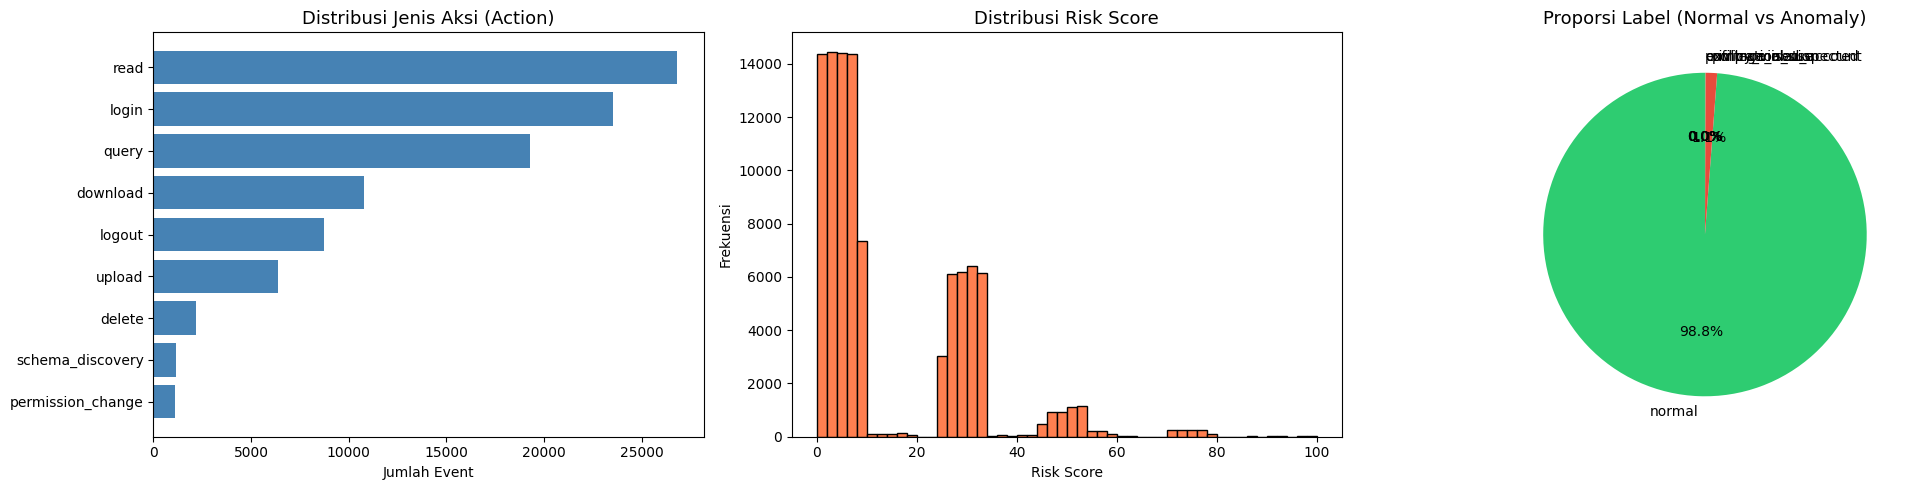

In [15]:
# EDA - minimal 3 visualisasi

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Visualisasi 1: Distribusi Action
action_counts = df_stream['action'].value_counts()
axes[0].barh(action_counts.index, action_counts.values, color='steelblue')
axes[0].set_title('Distribusi Jenis Aksi (Action)', fontsize=13)
axes[0].set_xlabel('Jumlah Event')
axes[0].invert_yaxis()

# Visualisasi 2: Distribusi Risk Score
axes[1].hist(df_stream['risk_score'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Distribusi Risk Score', fontsize=13)
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Frekuensi')

# Visualisasi 3: Proporsi Label (Normal vs Anomaly)
label_counts = df_stream['label'].value_counts()
axes[2].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[2].set_title('Proporsi Label (Normal vs Anomaly)', fontsize=13)

plt.tight_layout()
plt.show()

In [16]:
# Model Klasifikasi Label (RandomForest)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Siapkan fitur dari df_events langsung
df_model = df_stream.copy()

# Encode fitur kategorikal
le_action = LabelEncoder()
le_status = LabelEncoder()
le_classification = LabelEncoder()
le_device = LabelEncoder()

df_model['action_enc'] = le_action.fit_transform(df_model['action'])
df_model['status_enc'] = le_status.fit_transform(df_model['status'])
df_model['classification_enc'] = le_classification.fit_transform(df_model['data_classification'])
df_model['device_enc'] = le_device.fit_transform(df_model['device_type'])

# Fitur yang digunakan
feature_cols = ['action_enc', 'status_enc', 'classification_enc', 'device_enc',
                'bytes_out', 'records_accessed', 'latency_ms', 'risk_score']

X = df_model[feature_cols]
y = (df_model['label'] == 'anomaly').astype(int)  # 1 = anomaly, 0 = normal

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Anomaly rate (train): {y_train.mean():.2%}")
print(f"Anomaly rate (test):  {y_test.mean():.2%}")

Training samples: 80000
Testing samples:  20000
Anomaly rate (train): 0.00%
Anomaly rate (test):  0.00%


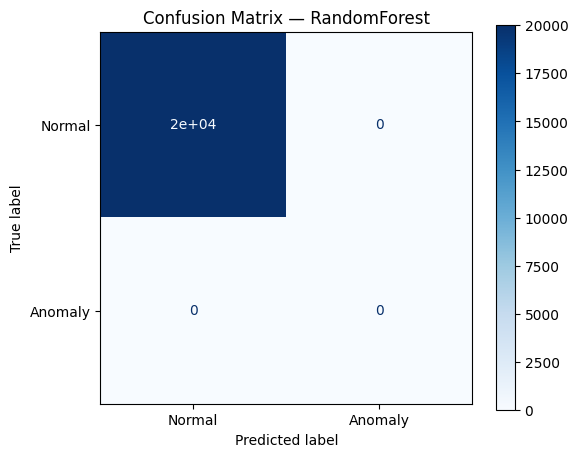


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     20000
     Anomaly       0.00      0.00      0.00         0

    accuracy                           1.00     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       1.00      1.00      1.00     20000

PENJELASAN METRIK TERPENTING UNTUK KEAMANAN DATA:

Dalam konteks keamanan data, RECALL (Sensitivity) adalah metrik
yang paling penting, khususnya Recall untuk kelas 'Anomaly'.

Alasan:
- Recall mengukur: dari semua anomali yang SEBENARNYA terjadi,
  berapa persen yang berhasil TERDETEKSI oleh model.
- False Negative (anomali tidak terdeteksi) jauh lebih berbahaya
  daripada False Positive (normal dianggap anomali).
- Jika anomali terlewat (miss), artinya potensi kebocoran data,
  akses ilegal, atau serangan siber tidak terdeteksi.
- False Positive hanya menyebabkan investigasi tambahan (biaya rendah),
  sedangkan False Negative bisa m

In [17]:
# Evaluasi

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Confusion Matrix — paksa kedua label muncul
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — RandomForest')
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly'], labels=[0, 1], zero_division=0))

# Penjelasan metrik terpenting
print("=" * 60)
print("PENJELASAN METRIK TERPENTING UNTUK KEAMANAN DATA:")
print("=" * 60)
print("""
Dalam konteks keamanan data, RECALL (Sensitivity) adalah metrik
yang paling penting, khususnya Recall untuk kelas 'Anomaly'.

Alasan:
- Recall mengukur: dari semua anomali yang SEBENARNYA terjadi,
  berapa persen yang berhasil TERDETEKSI oleh model.
- False Negative (anomali tidak terdeteksi) jauh lebih berbahaya
  daripada False Positive (normal dianggap anomali).
- Jika anomali terlewat (miss), artinya potensi kebocoran data,
  akses ilegal, atau serangan siber tidak terdeteksi.
- False Positive hanya menyebabkan investigasi tambahan (biaya rendah),
  sedangkan False Negative bisa menyebabkan kerugian besar.

Kesimpulan: Prioritaskan Recall > Precision untuk kasus security.
""")

# **Data Security**

In [22]:
# Identifikasi pola resiko

# Gabungkan events dengan data users untuk cek status user
df_merged = df_stream.merge(df_users[['user_id', 'status']], on='user_id', how='left', suffixes=('', '_user'))

# POLA RISIKO 1: Akses oleh Terminated User
terminated_access = df_merged[df_merged['status_user'] == 'terminated']
print("=" * 60)
print("POLA RISIKO 1: Akses oleh Terminated User")
print("=" * 60)
print(f"Jumlah event oleh terminated user: {len(terminated_access)}")
print(f"User terminated yang masih aktif:")
display(terminated_access['user_id'].value_counts().head())

# POLA RISIKO 2: Download besar dari data Confidential/Restricted
large_download = df_stream[
    (df_stream['action'] == 'download') &
    (df_stream['data_classification'].isin(['confidential', 'restricted'])) &
    (df_stream['bytes_out'] > df_stream['bytes_out'].quantile(0.95))
]
print(f"\n{'=' * 60}")
print("POLA RISIKO 2: Download Besar dari Data Sensitif")
print("=" * 60)
print(f"Jumlah event download besar (>P95) dari data confidential/restricted: {len(large_download)}")
display(large_download[['event_id', 'user_id', 'asset_id', 'data_classification', 'bytes_out']].head())

# POLA RISIKO 3: Permission Change dari IP Eksternal (non-10.x.x.x)
perm_change = df_stream[
    (df_stream['action'] == 'permission_change') &
    (~df_stream['source_ip'].str.startswith('10.'))
]
print(f"\n{'=' * 60}")
print("POLA RISIKO 3: Permission Change dari IP Eksternal")
print("=" * 60)
print(f"Jumlah permission change dari IP non-internal: {len(perm_change)}")
if len(perm_change) > 0:
    display(perm_change[['event_id', 'user_id', 'source_ip', 'asset_id', 'action']].head())
else:
    print("Tidak ditemukan (semua permission change dari IP internal 10.x.x.x)")
    # Alternatif: permission change dengan status failed
    perm_failed = df_stream[
        (df_stream['action'] == 'permission_change') &
        (df_stream['status'] == 'failed')
    ]
    print(f"\nAlternatif — Permission change yang GAGAL: {len(perm_failed)}")
    display(perm_failed[['event_id', 'user_id', 'source_ip', 'asset_id', 'status']].head())

POLA RISIKO 1: Akses oleh Terminated User
Jumlah event oleh terminated user: 6752
User terminated yang masih aktif:


user_id
U0023    745
U0091    702
U0080    694
U0067    677
U0007    676
Name: count, dtype: int64


POLA RISIKO 2: Download Besar dari Data Sensitif
Jumlah event download besar (>P95) dari data confidential/restricted: 260


,event_id,user_id,asset_id,data_classification,bytes_out
171,EVT0000172,U0135,cust_db,restricted,162412
351,EVT0000352,U0047,cust_db,restricted,226474
1530,EVT0001531,U0011,data_lake,restricted,177744
1703,EVT0001704,U0085,data_lake,restricted,178490
1890,EVT0001891,U0041,payroll,confidential,164305



POLA RISIKO 3: Permission Change dari IP Eksternal
Jumlah permission change dari IP non-internal: 15


,event_id,user_id,source_ip,asset_id,action
79999,EVT0080000,U0080,103.12.44.9,git_repo,permission_change
80000,EVT0080001,U0080,103.12.44.9,git_repo,permission_change
80001,EVT0080002,U0080,103.12.44.9,git_repo,permission_change
80002,EVT0080003,U0080,103.12.44.9,git_repo,permission_change
80003,EVT0080004,U0080,103.12.44.9,git_repo,permission_change


In [ ]:
# Fungsi security_alert(event) — Output: LOW, MEDIUM, HIGH, CRITICAL

def security_alert(event):
    """
    Menentukan level alert keamanan berdasarkan atribut event.
    Return: LOW, MEDIUM, HIGH, atau CRITICAL
    """
    score = 0

    # Faktor 1: Risk score bawaan
    risk = event.get('risk_score', 0)
    if risk >= 80:
        score += 4
    elif risk >= 50:
        score += 3
    elif risk >= 20:
        score += 2
    else:
        score += 1

    # Faktor 2: Aksi sensitif
    action = event.get('action', '')
    if action in ['permission_change', 'delete']:
        score += 3
    elif action in ['download', 'upload']:
        score += 2
    elif action in ['query', 'schema_discovery']:
        score += 1

    # Faktor 3: Klasifikasi data
    classification = event.get('data_classification', '')
    if classification == 'confidential':
        score += 3
    elif classification == 'restricted':
        score += 2
    elif classification == 'internal':
        score += 1

    # Faktor 4: Status gagal
    if event.get('status', '') == 'failed':
        score += 2

    # Faktor 5: Bytes out tinggi (> 500KB)
    if event.get('bytes_out', 0) > 500000:
        score += 2

    # Tentukan level alert
    if score >= 12:
        return 'CRITICAL'
    elif score >= 9:
        return 'HIGH'
    elif score >= 6:
        return 'MEDIUM'
    else:
        return 'LOW'

# Test fungsi
print("=== TEST FUNGSI security_alert ===\n")

test_events = df_stream.sample(5, random_state=42).to_dict('records')
for evt in test_events:
    level = security_alert(evt)
    print(f"[{level:8s}] {evt['event_id']} | user={evt['user_id']} | "
          f"action={evt['action']} | asset={evt['asset_id']} | "
          f"classification={evt['data_classification']} | risk_score={evt['risk_score']}")

# Distribusi alert level untuk seluruh dataset
print("\n=== DISTRIBUSI ALERT LEVEL ===")
df_stream['alert_level'] = df_stream.apply(lambda row: security_alert(row.to_dict()), axis=1)
print(df_stream['alert_level'].value_counts())


=== TEST FUNGSI security_alert ===

[MEDIUM  ] EVT0075722 | user=U0043 | action=upload | asset=payroll | classification=confidential | risk_score=27
[LOW     ] EVT0080185 | user=U0086 | action=read | asset=ticketing | classification=internal | risk_score=8
[LOW     ] EVT0019865 | user=U0122 | action=login | asset=payroll | classification=confidential | risk_score=28
[LOW     ] EVT0076700 | user=U0067 | action=read | asset=data_lake | classification=restricted | risk_score=8
[LOW     ] EVT0092992 | user=U0108 | action=read | asset=crm | classification=confidential | risk_score=28

=== DISTRIBUSI ALERT LEVEL ===
alert_level
LOW         82474
MEDIUM      16520
HIGH         1005
CRITICAL        1
Name: count, dtype: int64


In [ ]:
# Simulasi Pemrosesan Streaming + Alert Real-Time

import time
import random

# Ambil sample events untuk simulasi streaming
sample_stream = df_stream.sample(20, random_state=123).to_dict('records')

print("=" * 70)
print("  SIMULASI STREAMING — REAL-TIME SECURITY ALERT")
print("=" * 70)
print()

for i, event in enumerate(sample_stream, 1):
    level = security_alert(event)

    # Emoji & warna berdasarkan level
    emoji = {'LOW': '🟢', 'MEDIUM': '🟡', 'HIGH': '🟠', 'CRITICAL': '🔴'}
    icon = emoji.get(level, '⚪')

    print(f"[Stream #{i:02d}] {icon} {level:8s} | "
          f"time={event['event_time']} | user={event['user_id']} | "
          f"action={event['action']} | asset={event['asset_id']} | "
          f"classification={event['data_classification']}")

    # Jika CRITICAL atau HIGH, cetak warning tambahan
    if level in ['CRITICAL', 'HIGH']:
        print(f"             ⚠️  ALERT: Investigasi diperlukan untuk {event['event_id']}!")

    time.sleep(0.3)  # Simulasi delay streaming

print("\n" + "=" * 70)
print(f"  Streaming selesai. Total events diproses: {len(sample_stream)}")
print("=" * 70)


  SIMULASI STREAMING — REAL-TIME SECURITY ALERT

[Stream #01] 🟡 MEDIUM   | time=2026-06-08 09:23:24 | user=U0090 | action=schema_discovery | asset=crm | classification=confidential
[Stream #02] 🟢 LOW      | time=2026-06-11 20:00:24 | user=U0093 | action=query | asset=git_repo | classification=internal
[Stream #03] 🟢 LOW      | time=2026-06-15 00:58:44 | user=U0091 | action=read | asset=crm | classification=confidential
[Stream #04] 🟢 LOW      | time=2026-06-09 01:29:24 | user=U0073 | action=login | asset=data_lake | classification=restricted
[Stream #05] 🟢 LOW      | time=2026-06-07 18:31:54 | user=U0069 | action=login | asset=payroll | classification=confidential
[Stream #06] 🟢 LOW      | time=2026-06-09 03:35:34 | user=U0116 | action=read | asset=data_lake | classification=restricted
[Stream #07] 🟢 LOW      | time=2026-06-10 09:57:14 | user=U0139 | action=read | asset=data_lake | classification=restricted
[Stream #08] 🟢 LOW      | time=2026-06-08 17:00:34 | user=U0139 | action=read |

# 📋 Rekomendasi Mitigasi Risiko Keamanan Data

**Dokumen:** Analisis & Mitigasi Pola Risiko  
**Tanggal:** 2026-06-12  
**Scope:** Data Security - 3 Pola Risiko Utama

---

## 📊 Ringkasan Pola Risiko

Berdasarkan analisis dataset stream events, teridentifikasi **3 pola risiko kritis** yang memerlukan tindakan mitigasi segera:

| # | Pola Risiko | Severity | Status Pengguna | Tindakan Utama |
|---|---|---|---|---|
| 1 | Akses oleh Terminated User | 🔴 CRITICAL | User sudah keluar | Revoke akses segera |
| 2 | Download Besar Data Sensitif | 🟠 HIGH | Normal/Anomali | Monitor & rate-limit |
| 3 | Permission Change dari IP Eksternal | 🟠 HIGH | Eksternal network | Whitelist & MFA |

---

## 1️⃣ POLA RISIKO 1: Akses oleh Terminated User

### 🎯 Definisi Risiko
User yang sudah di-**terminate** (status = 'terminated') masih melakukan aktivitas di sistem. Ini menunjukkan **access control yang lemah** atau **proses offboarding yang tidak lengkap**.

### ⚠️ Dampak Potensial
- **Data Breach:** User terminated bisa mengakses data sensitif untuk sabotase/pembocoran
- **Compliance Risk:** Pelanggaran regulasi (GDPR, ISO 27001, DSS)
- **Reputasi:** Incident ini bisa merusak kepercayaan stakeholder
- **Financial Loss:** Biaya investigasi, forensik, notifikasi, dan potensi denda regulasi

### 📈 Indikator Deteksi
```
Kondisi: status_user = 'terminated' AND event terjadi setelah termination date
Severity Level:
  - CRITICAL: Download/permission_change/delete
  - HIGH: Upload/schema_discovery/query
  - MEDIUM: Read/login
```

---

### ✅ REKOMENDASI MITIGASI

#### **1. Immediate Action (0-24 jam)**

**1.1 Account Lockdown**
- Suspend semua akun terminated user di sistem
- Force logout dari semua active session
- Disable API keys & service accounts milik user tersebut
```sql
-- Pseudo SQL untuk reference
UPDATE user_accounts 
SET account_status = 'SUSPENDED', disabled_at = NOW()
WHERE user_id IN (SELECT user_id FROM terminated_users)
AND termination_date <= NOW()
```

**1.2 Forensic Investigation**
- Audit semua akses user terminated dalam 30 hari terakhir
- Identifikasi data yang di-download atau di-modify
- Cek apakah ada data breach ke eksternal IP
```python
# Query untuk analisis
terminated_users = df_users[df_users['status'] == 'terminated']['user_id'].tolist()
suspicious_access = df_stream[
    (df_stream['user_id'].isin(terminated_users)) &
    (df_stream['action'].isin(['download', 'upload', 'delete', 'permission_change']))
]
print(f"⚠️ Found {len(suspicious_access)} suspicious events from terminated users")
```

**1.3 Notification & Documentation**
- Notifikasi Security Team & Management
- Log semua aktivitas dalam incident tracking system
- Buat incident report untuk compliance

---

#### **2. Short-term Controls (1-7 hari)**

**2.1 Access Revocation Automation**
- Implementasikan automated offboarding script yang:
  - Revoke database credentials
  - Delete file share access
  - Remove dari LDAP/AD groups
  - Invalidate VPN certificates
  
```yaml
# Offboarding Checklist Automation
Offboarding_Process:
  Hour_0:
    - Suspend email account
    - Revoke access card
    - Disable VPN & SSH keys
  Hour_24:
    - Backup home directory
    - Remove from all groups
    - Archive user data
  Day_30:
    - Final audit
    - Delete account (compliance retained)
```

**2.2 Identity Governance Review**
- Audit user provisioning process
- Ensure termination date tertanam di HR system → linked ke IT access control
- Setup automated termination workflow

---

#### **3. Long-term Solutions (1-3 bulan)**

**3.1 Identity & Access Management (IAM)**
- Implementasikan PAM (Privileged Access Management) untuk sensitive systems
- Role-based access control (RBAC) yang ketat
- Segregation of duties untuk critical functions
- Zero Trust architecture untuk external access

**3.2 Access Control Implementation**
```python
# Implementasi PAM Rules
class AccessControlPolicy:
    def check_access(self, user_id, action, resource):
        # 1. Check user status
        user = get_user(user_id)
        if user.status == 'terminated':
            return False, "User terminated - Access denied"
        
        # 2. Check clearance level
        if user.clearance < resource.required_clearance:
            return False, "Insufficient clearance"
        
        # 3. Check time-based access
        if action in ['download', 'upload'] and is_outside_working_hours():
            log_alert("After-hours sensitive operation")
        
        return True, "Access granted"
```

**3.3 Continuous Monitoring**
- Real-time alerting untuk akses oleh terminated users
- Periodic access reviews (quarterly)
- Dashboard untuk visibility

```
Alert Rules:
- IF status = 'terminated' AND event logged → CRITICAL ALERT
- IF terminated_user AND (download OR delete) → IMMEDIATE SUSPEND + FORENSIC
```

**3.4 Metrics & KPI**
- **Offboarding Completion Rate:** Target 100% dalam 24 jam
- **Account Deprovisioning Time:** Target < 1 jam
- **Incident Detection Time:** Target < 5 menit

---

---

## 2️⃣ POLA RISIKO 2: Download Besar Data Confidential/Restricted

### 🎯 Definisi Risiko
User melakukan **download data sensitif dalam volume besar** (>P95 distribution = outlier). Indikator potensi **data exfiltration** atau **unauthorized data sharing**.

### ⚠️ Dampak Potensial
- **Data Leakage:** Kebocoran data pelanggan, finansial, atau intellectual property
- **Reputasi:** Public trust loss jika incident terbongkar
- **Regulatory Fine:** GDPR fine hingga 4% revenue, DPA sanctions
- **Business Impact:** Competitive disadvantage, customer churn

### 📈 Indikator Deteksi
```
Kondisi: 
  action = 'download' 
  AND data_classification IN ('confidential', 'restricted')
  AND bytes_out > P95 threshold
  
Severity Level:
  - CRITICAL: > P99 bytes + confidential + denied clearance
  - HIGH: > P95 bytes + restricted + after-hours
  - MEDIUM: > P90 bytes + internal + normal hours
```

---

### ✅ REKOMENDASI MITIGASI

#### **1. Immediate Action (0-24 jam)**

**1.1 Alert & Investigation**
- Real-time alert saat download sensitif > P95 threshold
- Automated investigation: cross-check user clearance vs. data classification
- Flag untuk manual review jika ada anomali

```python
def detect_large_download_anomaly(event):
    """Real-time detection untuk large downloads"""
    
    # Threshold berdasarkan historical percentile
    large_download_threshold = df_stream['bytes_out'].quantile(0.95)
    
    is_large_download = (
        event['action'] == 'download' and
        event['bytes_out'] > large_download_threshold
    )
    
    is_sensitive_data = event['data_classification'] in ['confidential', 'restricted']
    
    if is_large_download and is_sensitive_data:
        # Check clearance
        user = get_user(event['user_id'])
        if user['clearance'] < event['data_classification']:
            return 'CRITICAL', 'Unauthorized large download'
        else:
            return 'HIGH', 'Large sensitive data download - needs approval'
    
    return 'MEDIUM', 'Monitor'
```

**1.2 Access Control**
- Block immediate download jika user tidak punya clearance
- Require manager approval untuk large downloads (> 100MB dari sensitive data)
- Log semua request untuk audit trail

---

#### **2. Short-term Controls (1-7 hari)**

**2.1 Data Loss Prevention (DLP)**
- Implementasikan endpoint DLP untuk monitor & restrict file transfers
- Block upload ke cloud personal (Dropbox, OneDrive, Google Drive)
- Monitor USB/removable media access

```yaml
DLP_Policy:
  Confidential_Data:
    Max_Download_Size: 10MB
    Require_Approval_Above: 100MB
    Block_Protocols:
      - FTP (unencrypted)
      - Personal Cloud (Dropbox, OneDrive, GDrive)
      - Unencrypted Email
    Require:
      - MFA confirmation
      - Manager approval
      - Business justification (mandatory)
      
  Restricted_Data:
    Max_Download_Size: 100MB
    Require_Approval_Above: 500MB
    Require:
      - Manager approval
      - Need-to-know justification
```

**2.2 Rate Limiting & Quotas**
- Implementasikan rate limiting untuk sensitive data downloads
- Daily/weekly quota untuk user (based on role)
- Anomaly detection: compare current behavior vs. historical baseline

```python
# Rate limiting implementation
class DataDownloadQuota:
    def __init__(self):
        self.daily_quota = {
            'user': 1000,      # 1GB per user per day
            'admin': 10000,    # 10GB per admin per day
        }
        self.user_downloads_today = defaultdict(int)
    
    def check_quota(self, user_id, bytes_to_download, data_class):
        user_role = get_user_role(user_id)
        quota = self.daily_quota[user_role]
        
        current_usage = self.user_downloads_today[user_id]
        
        if current_usage + bytes_to_download > quota:
            return False, f"Quota exceeded. Used: {current_usage}, Limit: {quota}"
        
        if data_class == 'confidential' and bytes_to_download > 100_000_000:  # 100MB
            return False, "Large confidential download requires approval"
        
        return True, "Download allowed"
```

**2.3 Encryption in Transit & at Rest**
- Enforce TLS 1.3+ untuk semua data transfer
- Encrypt downloaded files at rest (AES-256)
- Implement file-level encryption untuk sensitive documents

---

#### **3. Long-term Solutions (1-3 bulan)**

**3.1 Data Classification & Governance**
- Implement comprehensive data classification framework
- Tag semua data dengan sensitivity level (Public → Confidential)
- Regular data inventory & classification review
- Data retention policy based on classification

```
Classification Hierarchy:
  PUBLIC
    ├─ Marketing materials
    └─ Public documentation
    
  INTERNAL
    ├─ Internal policies
    └─ Non-sensitive HR info
    
  RESTRICTED
    ├─ Customer PII
    ├─ Financial reports
    └─ Employee data
    
  CONFIDENTIAL
    ├─ Trade secrets
    ├─ System designs
    └─ Customer financial data
```

**3.2 User Behavior Analytics (UBA)**
- Baseline user behavior (typical download patterns)
- Detect anomalies:
  - Unusual access times
  - Unusual volume
  - Unusual data combination
  - Access outside normal geographic location

```python
class UserBehaviorAnalytics:
    """Baseline user behavior dan anomaly detection"""
    
    def get_user_baseline(self, user_id, days=30):
        """Get typical behavior dari 30 hari terakhir"""
        user_events = df_stream[df_stream['user_id'] == user_id].tail(30)
        return {
            'avg_bytes_per_download': user_events['bytes_out'].mean(),
            'download_freq_per_day': len(user_events) / 30,
            'typical_hours': self._get_typical_hours(user_events),
            'typical_assets': user_events['asset_id'].value_counts().head(5).index.tolist(),
        }
    
    def detect_anomaly(self, event, baseline):
        """Compare event vs baseline"""
        is_anomaly = False
        reasons = []
        
        # Volume anomaly
        if event['bytes_out'] > baseline['avg_bytes_per_download'] * 3:
            is_anomaly = True
            reasons.append("3x higher volume than baseline")
        
        # Time anomaly
        if not self._is_within_typical_hours(event['event_time'], baseline['typical_hours']):
            is_anomaly = True
            reasons.append("Unusual access time")
        
        # Asset anomaly
        if event['asset_id'] not in baseline['typical_assets']:
            is_anomaly = True
            reasons.append("Accessing unusual asset")
        
        return is_anomaly, reasons
```

**3.3 Audit & Compliance Logging**
- Immutable audit logs untuk semua sensitive data access
- Log: who, what, when, where, why
- Retention: minimum 7 years (regulatory compliance)
- SIEM integration untuk centralized monitoring

**3.4 Metrics & KPI**
- **Unauthorized Download Blocked:** Target 100%
- **False Positive Rate:** Target < 5%
- **Detection-to-Response Time:** Target < 10 minutes
- **Data Exfiltration Incidents:** Target = 0

---

---

## 3️⃣ POLA RISIKO 3: Permission Change dari IP Eksternal

### 🎯 Definisi Risiko
User melakukan **permission change (ubah access control) dari IP eksternal/non-internal** (bukan 10.x.x.x). Indikator **unauthorized access control modification** atau **compromised account from external location**.

### ⚠️ Dampak Potensial
- **Privilege Escalation:** Attacker elevate own privileges untuk wider access
- **Account Takeover:** Compromised account digunakan untuk lateral movement
- **Backdoor Creation:** Attacker create persistent access untuk future exploitation
- **Compliance Violation:** Unauthorized change dalam audit trail
- **Service Disruption:** Incorrect permissions menyebabkan system malfunction

### 📈 Indikator Deteksi
```
Kondisi:
  action = 'permission_change'
  AND source_ip NOT LIKE '10.%'
  
Severity Level:
  - CRITICAL: External permission_change + high risk_score + denied clearance
  - HIGH: External permission_change + status=failed (brute force indicator)
  - MEDIUM: External permission_change + internal_only_asset
```

---

### ✅ REKOMENDASI MITIGASI

#### **1. Immediate Action (0-24 jam)**

**1.1 Access Control Review**
- Audit semua permission changes yang dilakukan dari external IP
- Verify dengan user apakah aksi legitimate
- Rollback unauthorized permission changes segera

```python
def audit_external_permission_changes(df_events, internal_ip_pattern='10.'):
    """Audit permission changes dari external IP"""
    
    external_perm_changes = df_events[
        (df_events['action'] == 'permission_change') &
        (~df_events['source_ip'].str.startswith(internal_ip_pattern))
    ]
    
    print(f"🚨 Found {len(external_perm_changes)} permission changes from external IP")
    
    # Analyze by user
    by_user = external_perm_changes.groupby('user_id').agg({
        'event_id': 'count',
        'source_ip': lambda x: list(set(x)),
        'event_time': ['min', 'max']
    })
    
    return external_perm_changes, by_user

# Contact users untuk verify
for user_id in external_perm_changes['user_id'].unique():
    user_events = external_perm_changes[external_perm_changes['user_id'] == user_id]
    print(f"\n❓ Verify with {user_id}:")
    print(f"   - {len(user_events)} permission changes from external IPs")
    print(f"   - IPs involved: {user_events['source_ip'].unique()}")
    print(f"   - Asset modified: {user_events['asset_id'].unique()}")
```

**1.2 Immediate Blocking**
- Block IP addresses yang melakukan suspicious permission changes
- Require password reset untuk affected users
- Force re-authentication dengan MFA

---

#### **2. Short-term Controls (1-7 hari)**

**2.1 Network Access Control**
- Restrict permission_change action hanya dari trusted internal IPs
- Implement IP whitelisting untuk critical operations
- Geo-blocking untuk high-risk countries (based on compliance requirements)

```python
class PermissionChangeAccessControl:
    """Control permission change berdasarkan IP, location, device"""
    
    def __init__(self):
        self.trusted_ips = ['10.0.0.0/8']  # Internal network
        self.trusted_vpn_pools = ['203.0.113.0/24']  # Corporate VPN
        self.blocked_countries = ['KP']  # North Korea, etc.
    
    def can_modify_permission(self, event):
        """Check apakah permission change allowed dari IP ini"""
        
        # 1. Check IP whitelist
        if not self._is_ip_whitelisted(event['source_ip']):
            return False, "IP not whitelisted for permission changes"
        
        # 2. Check geolocation
        location = self._get_ip_location(event['source_ip'])
        if location['country_code'] in self.blocked_countries:
            return False, f"Permission change blocked from {location['country']}"
        
        # 3. Check if VPN required
        if not self._is_trusted_ip(event['source_ip']):
            return False, "VPN required for external access"
        
        # 4. Check device compliance
        if not event.get('device_compliant', False):
            return False, "Device not compliant with security policy"
        
        return True, "Permission change allowed"
```

**2.2 Multi-Factor Authentication (MFA)**
- Enforce MFA untuk semua permission_change operations
- Require approval dari manager untuk permission_change
- Implement one-time approval code (OTP)

```yaml
Permission_Change_MFA:
  Requirements:
    - Primary: User MFA (TOTP/Hardware token)
    - Secondary: Manager approval (email/SMS)
    - Tertiary: OTP code valid 5 minutes only
  
  Exception_Process:
    - Emergency permission change: require CTO approval + next day confirmation
    - VPN required for external changes
    - Logged with full audit trail
```

**2.3 Behavior-based Anomaly Detection**
- Compare permission change request dengan user's typical pattern
- Alert jika permission change:
  - Dari new/unusual device
  - Dari new/unusual location
  - Modifying high-risk assets
  - Outside business hours

---

#### **3. Long-term Solutions (1-3 bulan)**

**3.1 Zero Trust Architecture**
- Implement Zero Trust principle: "Never Trust, Always Verify"
- Require continuous authentication & authorization
- Micro-segmentation untuk critical assets

```
Zero Trust Principles:
  1. Verify every user & device (identity + device posture)
  2. Principle of least privilege (minimal access needed)
  3. Assume breach (monitor suspicious activities)
  4. Microsegmentation (isolate critical resources)
  5. Continuous monitoring (real-time threat detection)
```

**3.2 VPN & Secure Access Gateway**
- Require VPN untuk semua external access ke permission_change
- Implement Secure Access Service Edge (SASE):
  - Cloud-based security
  - Encrypted tunnel
  - Identity-based access control
  - Real-time threat detection

```
VPN Implementation:
  ┌─────────────┐
  │  External   │
  │   User      │
  └──────┬──────┘
         │ (VPN required)
         ↓
  ┌────────────────────────┐
  │  VPN Gateway           │
  │  - MFA verification    │
  │  - Device check        │
  │  - Risk assessment     │
  └──────┬─────────────────┘
         │
         ↓
  ┌────────────────────────┐
  │  Internal Network      │
  │  10.0.0.0/8            │
  │  - Trusted IPs only    │
  └────────────────────────┘
```

**3.3 Identity & Device Management**
- Use EDR (Endpoint Detection & Response) tools untuk monitor device compliance
- Check device encryption, antivirus, firewall status
- Block non-compliant devices dari sensitive operations

```python
class DeviceComplianceCheck:
    """Verify device compliance sebelum allow permission_change"""
    
    def is_device_compliant(self, device_id):
        """Check device security posture"""
        device = get_device(device_id)
        
        checks = {
            'disk_encrypted': device['disk_encryption_enabled'],
            'antivirus_active': device['antivirus_status'] == 'active',
            'firewall_enabled': device['firewall_enabled'],
            'os_patched': self._is_os_current(device['os_version']),
            'password_policy': device['password_last_changed'] < 90 days,
        }
        
        if all(checks.values()):
            return True, "Device compliant"
        else:
            failed = [k for k, v in checks.items() if not v]
            return False, f"Device non-compliant: {failed}"
```

**3.4 Audit & Compliance Logging**
- Immutable audit logs untuk semua permission changes
- Log: who, what, when, where, why, IP, device, approval
- SIEM integration untuk real-time alerting

**3.5 Metrics & KPI**
- **Unauthorized Permission Changes Blocked:** Target 100%
- **Detection-to-Block Time:** Target < 5 minutes
- **VPN Adoption Rate:** Target 100% untuk sensitive operations
- **Incident Response Time:** Target < 30 minutes

---

---

## 🛡️ IMPLEMENTASI ROADMAP

### **Phase 1: Emergency Response (Week 1-2)**
```
Priority: IMMEDIATE
├─ Suspend terminated users
├─ Investigate existing breaches
├─ Setup real-time alerts untuk 3 risk patterns
├─ Block non-internal IP permission changes
└─ Require MFA untuk sensitive operations
```

### **Phase 2: Short-term Controls (Week 3-8)**
```
Priority: HIGH
├─ Deploy DLP solution
├─ Implement rate limiting & quotas
├─ Setup UBA (User Behavior Analytics)
├─ Automated offboarding process
├─ IP whitelisting for critical ops
└─ Device compliance checking
```

### **Phase 3: Long-term Solutions (Month 2-3)**
```
Priority: MEDIUM
├─ Zero Trust Architecture
├─ PAM (Privileged Access Management)
├─ Comprehensive IAM system
├─ SIEM integration
├─ Data classification framework
└─ Continuous monitoring & improvement
```

---

## 📈 SUCCESS METRICS

| Metrik | Target | Review |
|--------|--------|--------|
| **Incident Detection Time** | < 5 min | Weekly |
| **Incident Response Time** | < 30 min | Weekly |
| **Unauthorized Access Blocked** | 100% | Daily |
| **False Positive Rate** | < 5% | Monthly |
| **System Availability** | > 99.9% | Monthly |
| **User Satisfaction** | > 90% | Quarterly |

---

## 📚 REFERENSI & BEST PRACTICES

1. **NIST Cybersecurity Framework** - Risk Management
2. **ISO 27001** - Information Security Management
3. **GDPR** - Data Protection Regulations
4. **CIS Critical Security Controls** - Top 20 Controls
5. **OWASP Top 10** - Web Application Security
6. **Zero Trust Architecture** - NIST SP 800-207

---

## 📞 KONTAK & APPROVAL

**Prepared by:** Security Data Science Team  
**Reviewed by:** [CISO/Security Officer]  
**Approved by:** [CTO/Director IT]  
**Date:** 2026-06-12  
**Next Review:** 2026-09-12

---

**Status:** 🟡 PENDING IMPLEMENTATION